In [14]:
import numpy as np 
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from PyTimeESR.ESR import ESR_fit_fun, guess_p0

In [ ]:
dat = np.loadtxt('Vdc_scan.dat')
use = dat[:,2] !=0
print(sum(use), len(use))
Zeeman = 17.027166936416716

50 50


In [18]:
Vdcs = dat[:,1]
Lamb = dat[:,2] - Zeeman
gamma = dat[:,3]
Is = dat[:,4]
Ia = dat[:,5]
Bxc0 = dat[:,6]
Bxc1 = dat[:,7]
Sz0 = dat[:,8]
Sz1 = dat[:,9]
T1 = dat[:,10]

/tmp/ipykernel_9199/3436587854.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


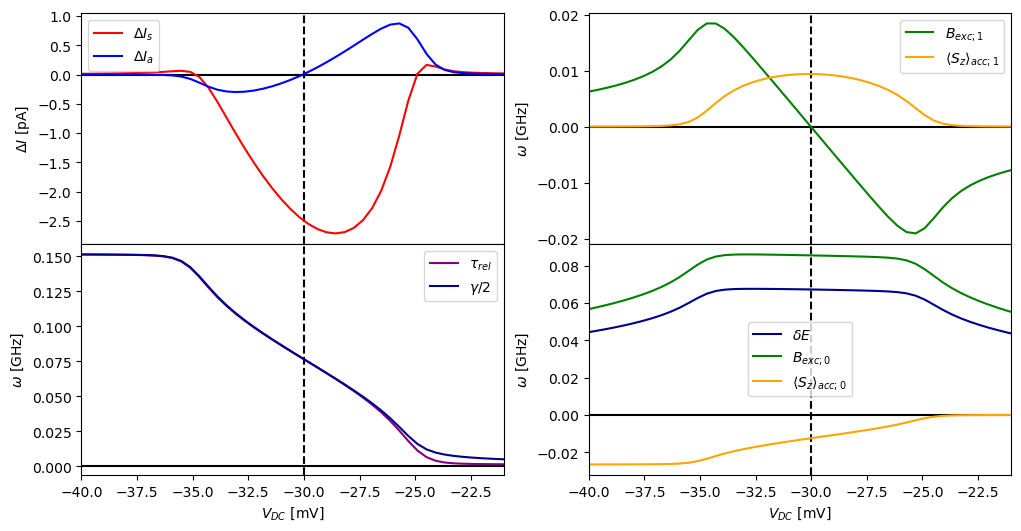

In [19]:
fig,ax = plt.subplots(2,2, figsize=(12,6), sharex=True)
ax= ax.flatten()
plt.subplots_adjust(hspace=0)

ax[3].plot(Vdcs, Lamb, 'darkblue', label=r'$\delta E$')
ax[3].plot(Vdcs, Bxc0, 'g', label=r'$B_{exc;0}$')
ax[3].plot(Vdcs, Sz0, 'orange', label=r'$\langle S_z \rangle_{acc;0}$')
ax[2].plot(Vdcs,  T1, 'purple', label=r'$\tau_{rel}$')
ax[2].plot(Vdcs, gamma/2, 'darkblue', label=r'$\gamma/2$')

ax[0].plot(Vdcs, Is, 'r', label=r'$\Delta I_s$')
ax[0].plot(Vdcs, Ia, 'b', label=r'$\Delta I_a$')
ax[1].plot(Vdcs, Bxc1, 'g', label=r'$B_{exc;1}$')
ax[1].plot(Vdcs, Sz1, 'orange', label=r'$\langle S_z \rangle_{acc;1}$')

for a in ax.flatten():
    a.set_xlim(-40, -21)
    xlim, ylim = a.get_xlim(), a.get_ylim()
    a.autoscale(False)

    #a.scatter([-35, -25], [0,0], c='black', marker='x', label=r'$\epsilon \pm V_{RF}$')
    a.hlines([0], xlim[0], xlim[1], 'k', '-', zorder=-1)
    a.vlines([-30], ylim[0], ylim[1], 'k', '--', zorder=-1)
    a.legend()

ax[2].set_ylabel(r'$\omega$ [GHz]')
ax[1].set_ylabel(r'$\omega$ [GHz]')
ax[3].set_ylabel(r'$\omega$ [GHz]')
ax[0].set_ylabel(r'$\Delta I$ [pA]')
ax[2].set_xlabel(r'$V_{DC}$ [mV]')
ax[3].set_xlabel(r'$V_{DC}$ [mV]')

fig.show()